In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import polars as pl
import matplotlib.pyplot as plt
from primary.preprocessing import cluster_purity
import plotly.express as px
import numpy as np
from primary.pdg_mappings import PDG_ID_TO_NAME

import numpy as np
import plotly.graph_objects as go
import ipywidgets as widgets
from collections import defaultdict, deque

/usr/wipp/conda/24.5.0u/envs/common/lib/python3.11/site-packages/sklearn/utils/_param_validation.py:11: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.3)
  from scipy.sparse import csr_matrix, issparse


In [3]:
from huggingface_hub import HfFileSystem
import polars as pl

fs = HfFileSystem()


with fs.open("datasets/OpenDataDetector/ColliderML-Release-1/data/ttbar_pu0_particles/train-00000-of-00100.parquet", "rb") as f:
    particles = pl.read_parquet(f)

with fs.open("datasets/OpenDataDetector/ColliderML-Release-1/data/ttbar_pu0_calo_hits/train-00000-of-00100.parquet", "rb") as f:
    calo_hits = pl.read_parquet(f)

with fs.open("datasets/OpenDataDetector/ColliderML-Release-1/data/ttbar_pu0_tracks/train-00000-of-00100.parquet", "rb") as f:
    tracks = pl.read_parquet(f)


In [4]:
from primary.preprocessing import add_orphan_mask, cast_parent_id_to_int64,add_created_inside_calo_mask, add_particle_have_track_mask,add_eta_and_phi,get_particles_id_parent_of_inside_calo_particles_mask, get_particles_id_parent_of_inside_calo_particles_maskv3
from primary.preprocessing import set_target_particles_mask
from primary.preprocessing import get_particles_id_parent_of_inside_calo_particles_maskv3
#particles = cast_parent_id_to_int64(particles)
particles = add_orphan_mask(particles)
particles = add_created_inside_calo_mask(particles)
particles = add_particle_have_track_mask(particles, tracks)
particles = add_eta_and_phi(particles)
particles = get_particles_id_parent_of_inside_calo_particles_maskv3(particles, calo_hits)
particles = set_target_particles_mask(particles)
particles


Computing parent existence mask...
Step 1: Building the Static Lookup Table (The Census)...
Step 2: initializing Active Paths for Depositors only...
Converged after 10 iterations on 4204335 depositors.
Preparing lineage map...
Converged after 5 iterations.


event_id,is_target_particle,enter_calo,has_track,particle_id,pdg_id,mass,energy,charge,vx,vy,vz,time,px,py,pz,perigee_d0,perigee_z0,vertex_primary,parent_id,primary,is_parent_missing,created_inside_calo,eta,phi,pt
u32,list[bool],list[bool],list[bool],list[u64],list[i64],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[f32],list[u16],list[i64],list[bool],list[bool],list[bool],list[f32],list[f32],list[f32]
649,"[false, false, … false]","[false, false, … false]","[false, false, … false]","[19, 20, … 4409]","[-213, 2224, … -11]","[0.915503, 1.209991, … 0.000511]","[1501.457886, 4882.183594, … 22.920151]","[-1.0, 2.0, … 1.0]","[-0.017771, -0.017771, … -16.878029]","[-0.003283, -0.003283, … -17.527498]","[-52.440014, -52.440014, … 2722.586182]","[0.297145, 0.297145, … 9.553991]","[0.15656, -0.15656, … -0.136922]","[0.277704, -0.277704, … -0.141287]","[1501.45752, 4882.183105, … 22.919306]","[NaN, NaN, … NaN]","[NaN, NaN, … NaN]","[1, 1, … 1]","[9, 9, … 4407]","[true, true, … false]","[true, true, … false]","[false, false, … false]","[9.150546, 10.329702, … 5.450978]","[1.057446, -2.084146, … -2.340506]","[0.318795, 0.318795, … 0.196748]"
908,"[true, true, … false]","[true, true, … false]","[false, false, … false]","[45, 46, … 7685]","[-321, 211, … 2112]","[0.49368, 0.13957, … 0.939565]","[2.897977, 1.741386, … 0.940269]","[-1.0, 1.0, … 0.0]","[-0.005302, -0.005302, … -98.723488]","[0.026734, 0.026734, … 1188.084106]","[86.26033, 86.26033, … 1222.162964]","[0.020885, 0.020885, … 116.923576]","[0.211317, 0.081697, … 0.015491]","[0.426406, -0.510454, … -0.029156]","[2.815683, 1.657018, … 0.015238]","[0.016622, -0.001011, … 470.260742]","[86.132538, 86.347633, … 1727.78186]","[1, 1, … 1]","[9, 9, … 7663]","[true, true, … false]","[true, true, … false]","[false, false, … true]","[2.477974, 1.881465, … 0.446548]","[1.110695, -1.412095, … -1.082417]","[0.475896, 0.51695, … 0.033016]"
387,"[false, false, … false]","[false, false, … false]","[false, false, … false]","[104, 105, … 9594]","[213, -211, … 22]","[0.735179, 0.13957, … 0.0]","[118.035141, 49.929668, … 9.478293]","[1.0, -1.0, … 0.0]","[-0.018042, -0.018042, … 24.540348]","[0.018347, 0.018347, … 44.978424]","[92.717186, 92.717186, … -1320.670776]","[0.010941, 0.010941, … 4.728593]","[1.726296, 0.712598, … 0.152364]","[4.516778, 1.302677, … 0.311263]","[-117.933762, -49.907391, … -9.471955]","[0.023403, 0.024633, … -2.266319]","[92.978065, 92.967155, … 78.375572]","[1, 1, … 1]","[7, 7, … 9590]","[true, true, … false]","[true, true, … false]","[false, false, … false]","[-3.887719, -4.208232, … -4.001538]","[1.205732, 1.07024, … 1.115582]","[4.83543, 1.484844, … 0.346554]"
128,"[false, false, … false]","[false, false, … false]","[false, false, … false]","[72, 73, … 5745]","[-211, 111, … 22]","[0.13957, 0.13498, … 0.0]","[14.697523, 28.742641, … 10.422291]","[-1.0, 0.0, … 0.0]","[0.008799, 0.008799, … 0.008619]","[0.012207, 0.012207, … 0.011928]","[-19.32469, -19.32469, … -19.313713]","[-0.047147, -0.047147, … -0.047111]","[0.515557, -0.469452, … -0.170177]","[-0.546971, -0.728459, … -0.329013]","[14.677627, 28.729256, … 10.415706]","[0.014775, 0.000784, … 0.002176]","[-19.269085, -18.826542, … -18.904451]","[1, 1, … 1]","[8, 8, … 73]","[true, true, … false]","[true, true, … false]","[false, false, … false]","[3.665613, 4.194441, … 4.0299]","[-0.814955, -2.143257, … -2.048136]","[0.751649, 0.866624, … 0.370419]"
131,"[false, false, … false]","[false, false, … false]","[false, false, … false]","[43, 44, … 9043]","[211, 221, … 22]","[0.13957, 0.54785, … 0.0]","[8.151142, 19.817646, … 63.988785]","[1.0, 0.0, … 0.0]","[0.01528, 0.01528, … 0.015222]","[-0.022616, -0.022616, … -0.022674]","[-49.630566, -49.630566, … -49.611897]","[-0.149263, -0.149263, … -0.1492]","[0.113887, 0.052817, … -0.149605]","[0.238678, -1.21521, … -0.230792]","[8.145656, 19.772694, … 63.988194]","[-0.023531, 0.014284, … 0.0]","[-49.204544, -50.008648, …

In [35]:
from primary.preprocessing import add_cluster_labels
calo = add_cluster_labels(
    calo_hits=(
        calo_hits.filter(pl.col("event_id") <1000)
    ), R=0.4)

Preparing data...
Distributing 1000 events across 32 cores...
Aggregating results...


In [39]:
from primary.preprocessing import backtrack_to_target
target = (particles.lazy()
        .select(['event_id','particle_id', 'is_target_particle'])
          .explode(['is_target_particle', 'particle_id'])
          .filter(pl.col('is_target_particle'))
          ).collect(streaming=True)
base  =(
        calo_hits.lazy()
        .select(['event_id', 'contrib_particle_ids'])
        .explode('contrib_particle_ids')
        .explode('contrib_particle_ids') # Double explode if list[list]
        .rename({'contrib_particle_ids': 'particle_id'})
        .unique(subset=['event_id', 'particle_id'])
        .select([
            pl.col('event_id'),
            pl.col('particle_id').cast(pl.Int64)
        ])
    )
result = backtrack_to_target(particles, src_df=base, target_df=target)
result

/tmp/ipykernel_798826/2526740024.py:6: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  ).collect(streaming=True)


Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 12 iterations.
Step 4: Final validation...


event_id,src_particle_id,target_particle_id
u32,i64,i64
496,643,594
496,3708,577
496,3760,577
496,3747,577
496,635,594
…,…,…
865,92,92
896,3896,3865
897,1982,419


In [40]:
from primary.preprocessing import cluster_purity
pur = cluster_purity(calo, result)

In [41]:
from primary.preprocessing import number_of_particles_per_cluster,number_of_clusters_per_particle
p = number_of_particles_per_cluster(calo, result, cut_off_percent=0.05)
c = number_of_clusters_per_particle(calo, result, cut_off_percent=0.05)

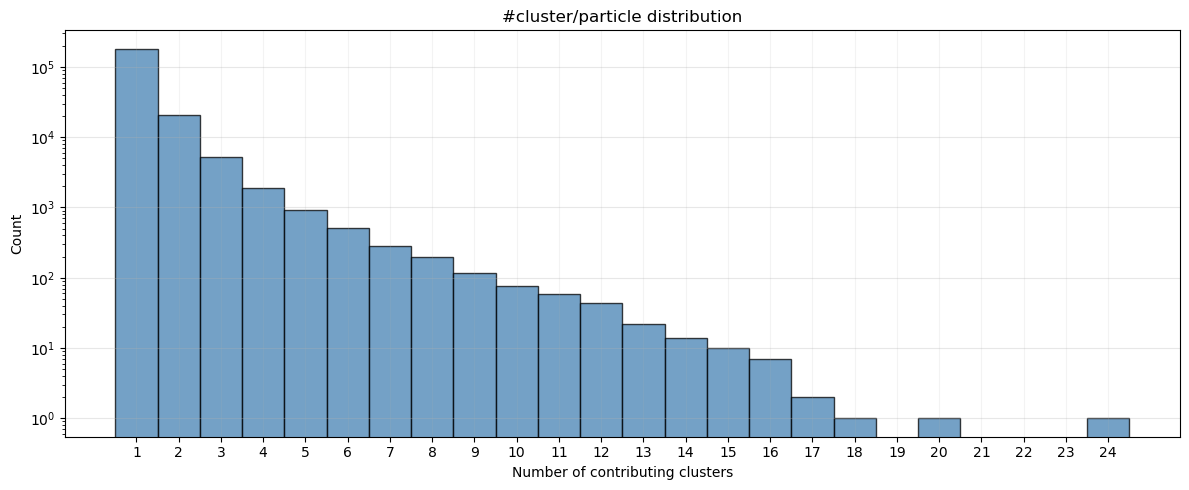

In [42]:
import numpy as np
import matplotlib.pyplot as plt
ancestor_stats = c
# 1. Get the data
data = ancestor_stats["num_contributing_clusters"].to_numpy()

# 2. Calculate min/max to define discrete integer bins
min_val = int(data.min())
max_val = int(data.max())

# Create bins that wrap around the integers: [0.5, 1.5, 2.5, ...]
# This ensures the bar for "1" is centered exactly on 1.
bins = np.arange(min_val - 0.5, max_val + 1.5, 1)

# 3. Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(data, bins=bins, color="steelblue", edgecolor="black", alpha=0.75)

# 4. Force X-axis ticks to show every single integer
ax.set_xticks(range(min_val, max_val + 1))
ax.set_xlabel("Number of contributing clusters")
ax.set_ylabel("Count")
ax.set_title("#cluster/particle distribution")

# 5. Grid settings
# 'axis="x"' puts vertical lines between the values to separate them visually
# or strictly on the ticks depending on how matplotlib renders the layout.
ax.grid(axis="y", alpha=0.3) 
ax.grid(axis="x", alpha=0.15) # Add faint vertical grid lines for clarity
# log scale
ax.set_yscale("log")
plt.tight_layout()
plt.show()

In [16]:
c.sort('num_contributing_clusters', descending=True)

event_id,ultimate_ancestor_id,num_contributing_clusters,max_ancestor_energy_deps_in_cluster
u32,i64,u32,f64
31,482,24,58.629905
9,945,16,11.431023
21,381,15,27.446833
7,718,15,110.057691
0,94,15,16.471967
…,…,…,…
39,4947,1,0.6937
7,689,1,0.672084
74,950,1,1.654606


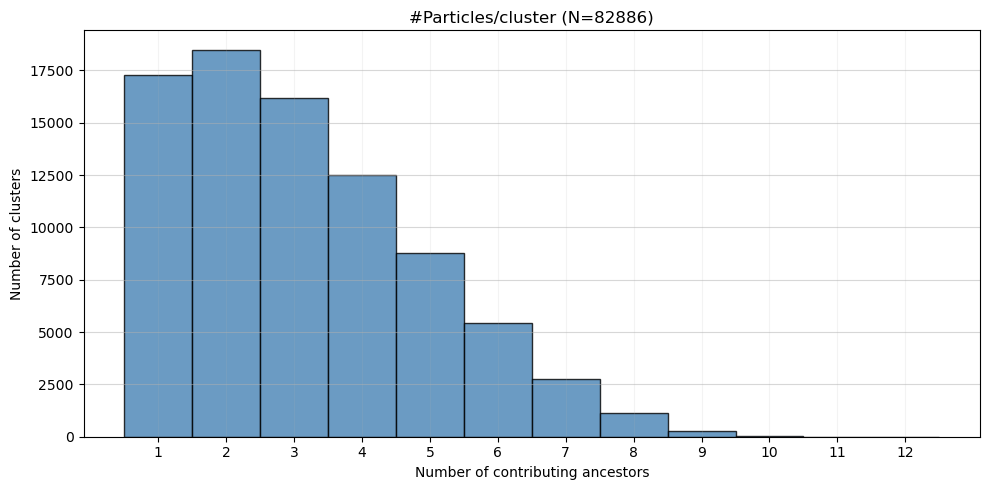

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib.ticker import MaxNLocator

def plot_num_contributing_ancestors(cluster_stats_df: pl.DataFrame, log_scale: bool = False) -> None:
    """
    Histogram of 'num_contributing_ancestors' where every integer has its own explicit bar.
    """
    vals = cluster_stats_df["num_contributing_ancestors"].to_numpy()
    
    if len(vals) == 0:
        print("No data to plot.")
        return

    # 1. Determine Range for Discrete Bins
    min_val = int(vals.min())
    max_val = int(vals.max())
    
    # Create bins centered on integers: [0.5, 1.5, 2.5, ...]
    # This ensures the bar for "1" is exactly between 0.5 and 1.5
    discrete_bins = np.arange(min_val - 0.5, max_val + 1.5, 1)

    # 2. Plot
    plt.figure(figsize=(10, 5))
    plt.hist(vals, bins=discrete_bins, color="steelblue", edgecolor="black", alpha=0.8)
    
    plt.xlabel("Number of contributing ancestors")
    plt.ylabel("Number of clusters")
    plt.title(f"#Particles/cluster (N={len(vals)})")

    # 3. Handle Ticks
    # If the range is small (e.g., 1 to 20), show every single number.
    # If the range is huge, let Matplotlib pick, but force them to be Integers.
    if max_val - min_val <= 30:
        plt.xticks(range(min_val, max_val + 1))
    else:
        plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    # 4. Log Scale & Grid
    if log_scale:
        plt.yscale("log")
        plt.ylabel("Number of clusters (log scale)")
    
    plt.grid(axis="y", alpha=0.5)
    plt.grid(axis="x", alpha=0.15) # Faint vertical lines to separate values
    plt.tight_layout()
    plt.show()
# ...existing code...

plot_num_contributing_ancestors(p, log_scale=False)

/tmp/ipykernel_2693847/3461637387.py:6: DeprecationWarning: `count` was renamed; use `len` instead
  .count()
/tmp/ipykernel_2693847/3461637387.py:15: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("num_clusters"),


,event_id,num_clusters,max_cluster_size
0,0,73,2424
1,1,73,3186
2,2,75,4697
3,3,83,2693
4,4,88,2496
...,...,...,...
95,95,86,2959
96,96,97,4191
97,97,85,15708
98,98,89,4929


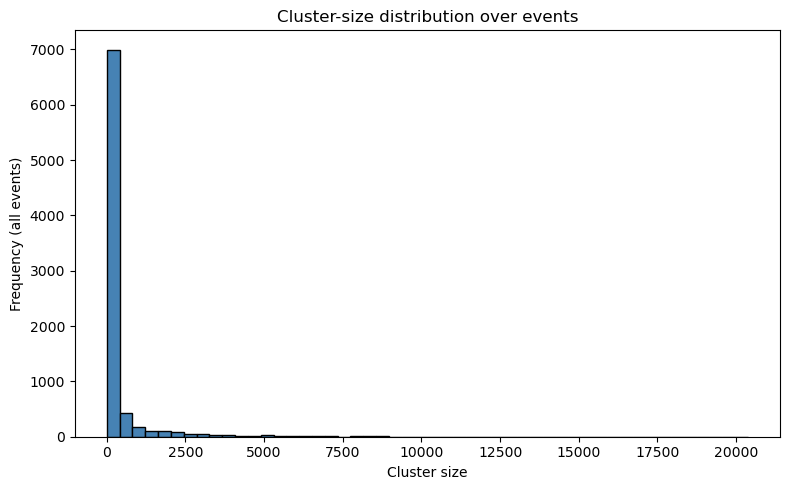

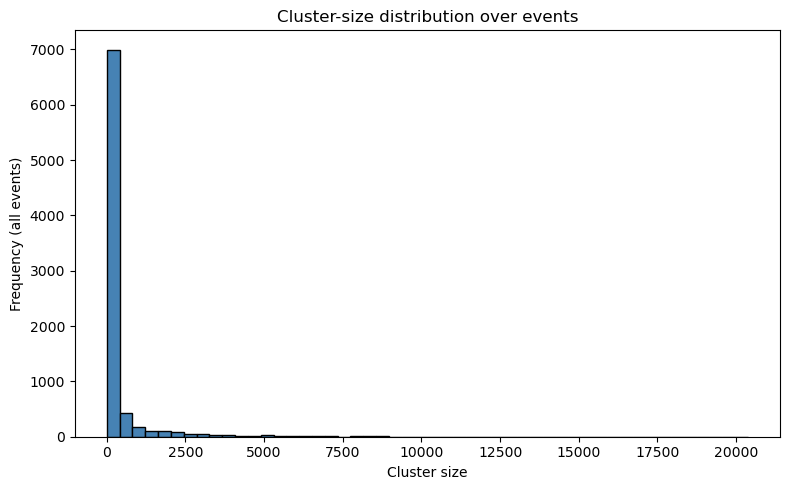

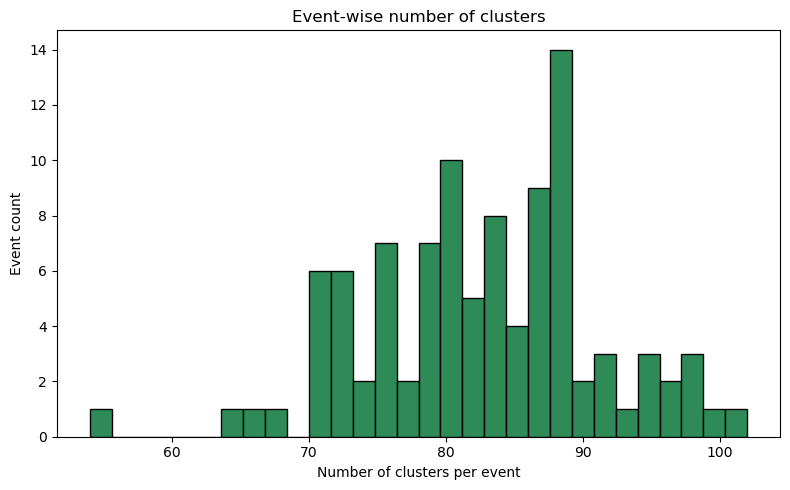

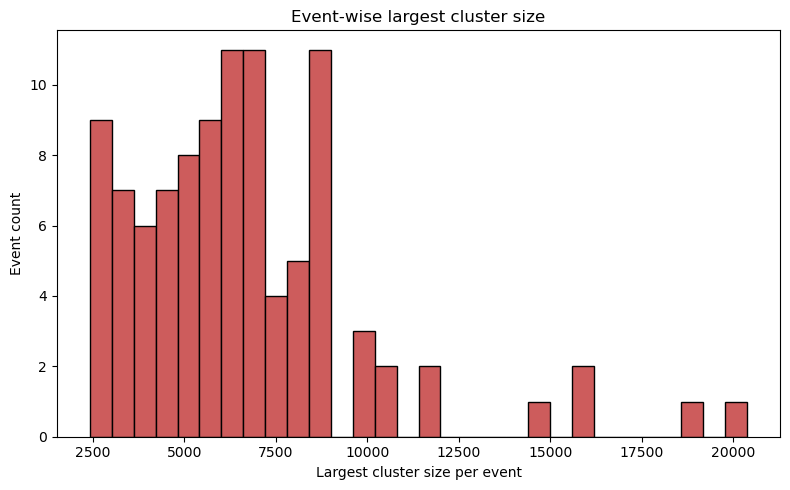

In [18]:
cluster_stats = (
    calo.lazy()
    .select(["event_id", "cluster_id"])
    .explode("cluster_id")
    .group_by(["event_id", "cluster_id"])
    .count()
    .rename({"count": "cluster_size"})
    .collect()
)

event_summary = (
    cluster_stats.lazy()
    .group_by("event_id")
    .agg([
        pl.count().alias("num_clusters"),
        pl.col("cluster_size").max().alias("max_cluster_size"),
    ])
    .sort("event_id")
    .collect()
)

display(event_summary.to_pandas())

plt.figure(figsize=(8, 5))
plt.hist(cluster_stats["cluster_size"].to_numpy(), bins=50, color="steelblue", edgecolor="black")
plt.xlabel("Cluster size")
plt.ylabel("Frequency (all events)")
plt.title("Cluster-size distribution over events")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(cluster_stats["cluster_size"].to_numpy(), bins=50, color="steelblue", edgecolor="black")
plt.xlabel("Cluster size")
plt.ylabel("Frequency (all events)")
plt.title("Cluster-size distribution over events")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(event_summary["num_clusters"].to_numpy(), bins=30, color="seagreen", edgecolor="black")
plt.xlabel("Number of clusters per event")
plt.ylabel("Event count")
plt.title("Event-wise number of clusters")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(event_summary["max_cluster_size"].to_numpy(), bins=30, color="indianred", edgecolor="black")
plt.xlabel("Largest cluster size per event")
plt.ylabel("Event count")
plt.title("Event-wise largest cluster size")
plt.tight_layout()
plt.show()

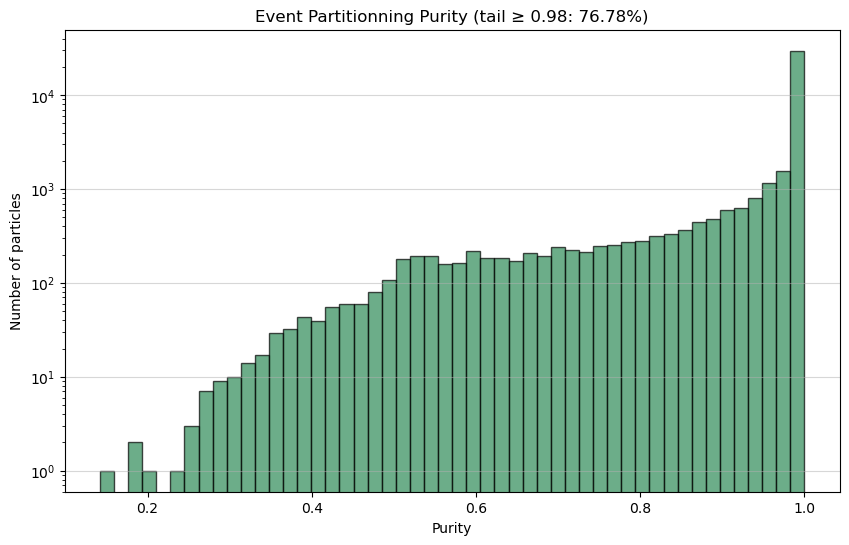

In [22]:
from primary.plot import plot_clusters_purity
purity_df = plot_clusters_purity(calo, result)

/tmp/ipykernel_2502228/2526740024.py:6: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  ).collect(streaming=True)


Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 12 iterations.
Step 4: Final validation...


event_id,src_particle_id,target_particle_id
u32,i64,i64
7,8378,8168
7,8210,8168
7,8374,8168
7,8230,8168
7,8237,8168
…,…,…
509,4365,875
509,4361,875
510,1070,1070


In [35]:
import fastjet
import numpy as np

# 1. Prepare Data & Set Indices
# It is CRITICAL to set_user_index(i) so we know which cell is which after clustering
particles_with_id = []
for i in range(len(px)):
    pj = fastjet.PseudoJet(px[i], py[i], pz[i], E[i])
    pj.set_user_index(i)  # <--- Stores the original index 'i'
    particles_with_id.append(pj)

# 2. Run Clustering (Inclusive, ptmin=0.0 to keep ALL cells)
R = 0.4
jet_def = fastjet.JetDefinition(fastjet.kt_algorithm, R)
cs = fastjet.ClusterSequence(particles_with_id, jet_def)
partitions = cs.inclusive_jets(ptmin=0.0)

# ---------------------------------------------------------
# 3. Generate the Label Array
# ---------------------------------------------------------

# Initialize with -1 to detect any missing cells (though ptmin=0.0 prevents this)
num_cells = len(px)
cluster_labels = np.full(num_cells, -1, dtype=np.int32)

# Iterate over each cluster and assign its ID to the constituent cells
for cluster_id, partition in enumerate(partitions):
    # Get the original indices of cells in this cluster
    constituents = partition.constituents()
    
    for c in constituents:
        original_idx = c.user_index()
        cluster_labels[original_idx] = cluster_id

# ---------------------------------------------------------
# 4. Result
# ---------------------------------------------------------
print("Cluster Labels:", cluster_labels)

# Verification
if -1 in cluster_labels:
    print("WARNING: Some cells were not assigned to a cluster!")
else:
    print("Success: All cells assigned.")

# Example Output check
# If cells 0 and 1 are in cluster 5, and cells 2 and 3 are in cluster 8:
# Output: [5, 5, 8, 8, ...]

Cluster Labels: [ 0  2 36 ...  0  3  0]
Success: All cells assigned.


In [36]:
cluster_labels

array([ 0,  2, 36, ...,  0,  3,  0], shape=(43951,), dtype=int32)

In [34]:
constituents[0].user_index()

39578

In [6]:
(
    calo_hits.lazy()
    .filter(pl.col("event_id") == 5)
    .select('x', 'y', 'z', 'total_energy')
    .explode('x', 'y', 'z', 'total_energy')
).collect(streaming=True)

/tmp/ipykernel_2501669/974053181.py:6: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  ).collect(streaming=True)


x,y,z,total_energy
f32,f32,f32,f32
353.82843,505.29071,3263.0,0.000127
-439.516754,-1260.991455,40.799999,0.000505
1129.478394,313.279694,3318.550049,0.018525
-86.699997,1272.599976,1203.599976,0.001721
-56.099998,367.788971,3232.699951,0.000137
…,…,…,…
927.221313,-681.996704,3293.300049,0.000211
-681.996704,-537.746887,3323.600098,0.000278
726.764343,-1072.963867,2779.5,0.000352
